<a href="https://colab.research.google.com/github/Jay-PhDAI/PhDAI_732_GP1/blob/main/GROUP_PROJECT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import sys
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
from sklearn.preprocessing import MinMaxScaler

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import requests
import matplotlib.pyplot as plt
import numpy as np

!pip install scikit-surprise
from surprise.model_selection import train_test_split
from surprise import Dataset, Reader

Function to download and import the dataset from my Github.

In [34]:
def load_data(filename):
    # Define the target path for the final file
    final_dir = Path("datasets/movie")
    # The file name as found in the GitHub repository
    source_filename = filename
    final_path = final_dir / source_filename

    # Ensure the target directory exists
    final_dir.mkdir(parents=True, exist_ok=True)

    # If the final parquet file does not exist, proceed with download
    if not final_path.is_file():

        # Correct URL for raw GitHub content, assuming 'main' branch and correct path within repo
        url = f"https://raw.githubusercontent.com/Jay-PhDAI/PhDAI_732_GP1/main/ml-100k/{source_filename}"

        # Define a temporary path to download the file to first
        temp_download_path = final_dir / source_filename

        print(f"Downloading data from: {url} using requests library")
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(temp_download_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded to: {temp_download_path}")

    else:
        print(f"File already exists: {final_path}. Skipping download.")

    # Directly read the final file
    return pd.read_table(final_path)

Load the dataframe.

In [35]:
movie = load_data("u.data")

File already exists: datasets/movie/u.data. Skipping download.


In [36]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   196        99999 non-null  int64
 1   242        99999 non-null  int64
 2   3          99999 non-null  int64
 3   881250949  99999 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [37]:
# Convert Unix timestamps (seconds) to datetime
movie['datetime'] = pd.to_datetime(movie['881250949'], unit='s')

print(movie['datetime'])

0       1998-04-04 19:22:22
1       1997-11-07 07:18:36
2       1997-11-27 05:02:03
3       1998-02-02 05:33:16
4       1998-01-07 14:20:06
                ...        
99994   1997-11-22 05:10:44
99995   1997-11-17 19:39:03
99996   1997-09-20 22:49:55
99997   1997-12-17 22:52:36
99998   1997-11-19 17:13:03
Name: datetime, Length: 99999, dtype: datetime64[ns]


In [38]:
print(movie)

       196   242  3  881250949            datetime
0      186   302  3  891717742 1998-04-04 19:22:22
1       22   377  1  878887116 1997-11-07 07:18:36
2      244    51  2  880606923 1997-11-27 05:02:03
3      166   346  1  886397596 1998-02-02 05:33:16
4      298   474  4  884182806 1998-01-07 14:20:06
...    ...   ... ..        ...                 ...
99994  880   476  3  880175444 1997-11-22 05:10:44
99995  716   204  5  879795543 1997-11-17 19:39:03
99996  276  1090  1  874795795 1997-09-20 22:49:55
99997   13   225  2  882399156 1997-12-17 22:52:36
99998   12   203  3  879959583 1997-11-19 17:13:03

[99999 rows x 5 columns]


In [39]:
movie.columns = ['UserID', 'ItemID', 'Rating', 'UnixTime(s)', 'Datetime']

In [40]:
print(movie)

       UserID  ItemID  Rating  UnixTime(s)            Datetime
0         186     302       3    891717742 1998-04-04 19:22:22
1          22     377       1    878887116 1997-11-07 07:18:36
2         244      51       2    880606923 1997-11-27 05:02:03
3         166     346       1    886397596 1998-02-02 05:33:16
4         298     474       4    884182806 1998-01-07 14:20:06
...       ...     ...     ...          ...                 ...
99994     880     476       3    880175444 1997-11-22 05:10:44
99995     716     204       5    879795543 1997-11-17 19:39:03
99996     276    1090       1    874795795 1997-09-20 22:49:55
99997      13     225       2    882399156 1997-12-17 22:52:36
99998      12     203       3    879959583 1997-11-19 17:13:03

[99999 rows x 5 columns]


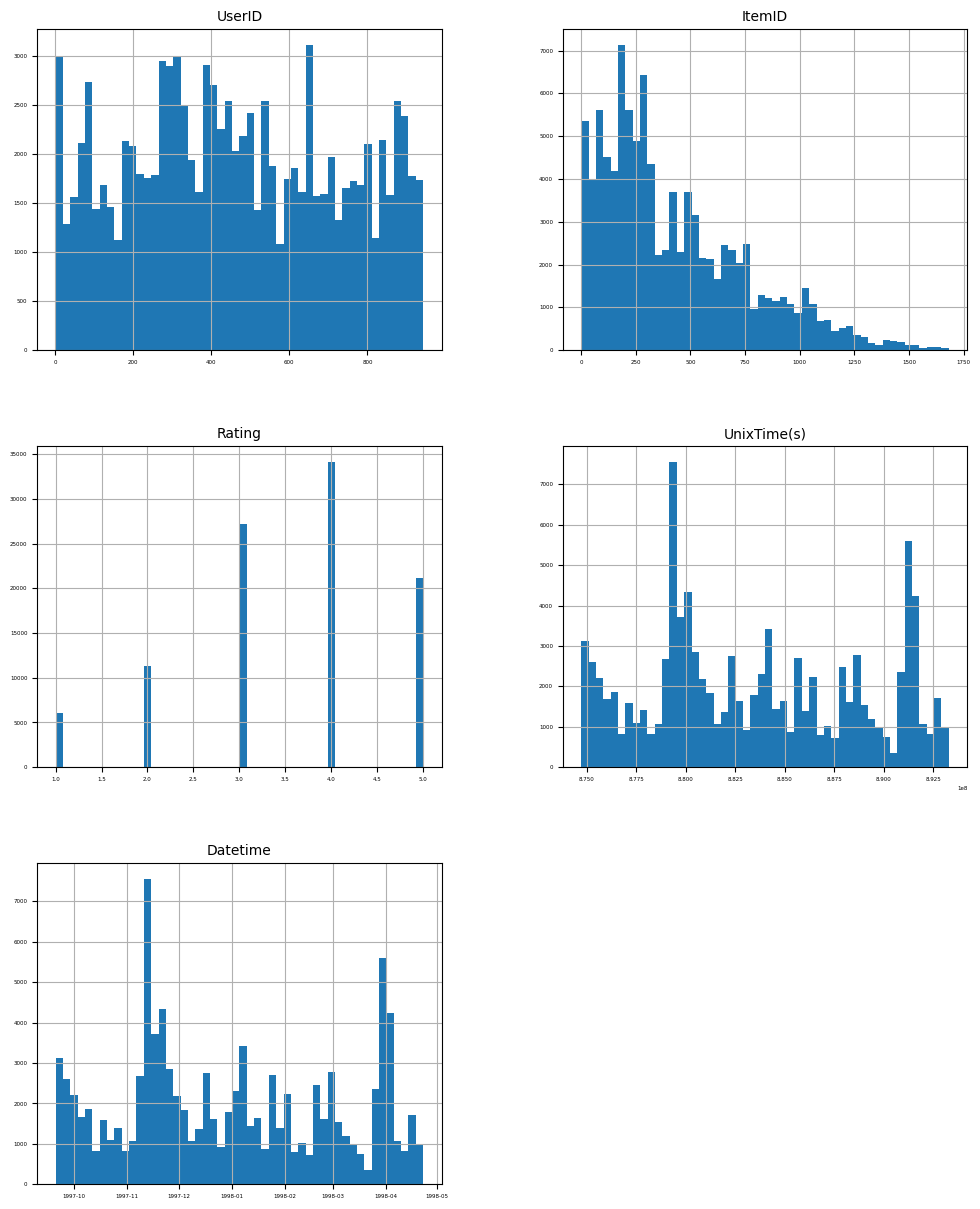

In [41]:
plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=4)
plt.rc('ytick', labelsize=4)

movie.hist(bins=50,figsize=(12, 15))
plt.show()

In [42]:
movie.describe()

,UserID,ItemID,Rating,UnixTime(s),Datetime
count,99999.000000,99999.000000,99999.000000,9.999900e+04,99999
mean,462.487415,425.531965,3.529865,8.835289e+08,1997-12-31 00:41:14.267872640
min,1.000000,1.000000,1.000000,8.747247e+08,1997-09-20 03:05:10
25%,254.000000,175.000000,3.000000,8.794487e+08,1997-11-13 19:18:24
50%,447.000000,322.000000,4.000000,8.828269e+08,1997-12-22 21:42:24
75%,682.000000,631.000000,4.000000,8.882600e+08,1998-02-23 18:53:04
max,943.000000,1682.000000,5.000000,8.932866e+08,1998-04-22 23:10:38
std,266.614421,330.799501,1.125678,5.343878e+06,NaN


In [43]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   UserID       99999 non-null  int64         
 1   ItemID       99999 non-null  int64         
 2   Rating       99999 non-null  int64         
 3   UnixTime(s)  99999 non-null  int64         
 4   Datetime     99999 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(4)
memory usage: 3.8 MB


In [44]:
movie.UserID.value_counts()

,count
UserID,
405,737
655,685
13,636
450,540
276,518
...,...
873,20
866,20
418,20


Ensure the IDs are integers and ratings are floats.

In [45]:
movie['UserID'] = movie['UserID'].astype(int)
movie['ItemID'] = movie['ItemID'].astype(int)
movie['Rating'] = movie['Rating'].astype(float)

In [46]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   UserID       99999 non-null  int64         
 1   ItemID       99999 non-null  int64         
 2   Rating       99999 non-null  float64       
 3   UnixTime(s)  99999 non-null  int64         
 4   Datetime     99999 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 3.8 MB


In [47]:
movie.Rating.value_counts()

,count
Rating,
4.0,34174
3.0,27144
5.0,21201
2.0,11370
1.0,6110


In [48]:
movie.groupby('UserID')['Rating'].describe()

,count,mean,std,min,25%,50%,75%,max
UserID,,,,,,,,
1,272.0,3.610294,1.263585,1.0,3.0,4.0,5.0,5.0
2,62.0,3.709677,1.030472,1.0,3.0,4.0,4.0,5.0
3,54.0,2.796296,1.219026,1.0,2.0,3.0,4.0,5.0
4,24.0,4.333333,0.916831,2.0,4.0,5.0,5.0,5.0
5,175.0,2.874286,1.362963,1.0,2.0,3.0,4.0,5.0
...,...,...,...,...,...,...,...,...
939,49.0,4.265306,0.974156,2.0,4.0,5.0,5.0,5.0
940,107.0,3.457944,1.012007,1.0,3.0,4.0,4.0,5.0
941,22.0,4.045455,0.898532,2.0,4.0,4.0,5.0,5.0


In [49]:
movie.groupby('UserID')['Rating'].mean()

,Rating
UserID,
1,3.610294
2,3.709677
3,2.796296
4,4.333333
5,2.874286
...,...
939,4.265306
940,3.457944
941,4.045455


Cleaning the dataframe to have 3 columns, UserID, ItemID and Rating. Saving this table as a dataframe named data.

Using surprise library to load the clean data into data_surprise object (we needed to create a reader object for the rating scale).

Splitting into training set and testing set.

In [50]:
data = movie.drop(columns=['UnixTime(s)', 'Datetime'])
data.info()

# Initialize Reader and load dataset
reader = Reader(rating_scale=(1, 5))

# Columns must be in order: userID, itemID, rating
data_surprise= Dataset.load_from_df(movie[['UserID', 'ItemID', 'Rating']], reader)

trainset, testset = train_test_split(data_surprise, test_size=0.25)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   UserID  99999 non-null  int64  
 1   ItemID  99999 non-null  int64  
 2   Rating  99999 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.3 MB
